In [1]:
print("="*80)
print("HYPERPARAMETER TUNING")
print("RANDOM FOREST CLASSIFIER")
print("="*80)

HYPERPARAMETER TUNING
RANDOM FOREST CLASSIFIER


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [5]:
route_dataset_df = pd.read_pickle(
    "../data/processed/route_dataset.pkl"
)

print(route_dataset_df.shape)

(19647, 15)


In [8]:
print(route_dataset_df.columns)

print()
print(route_dataset_df["Label"].value_counts())

print()
print(route_dataset_df["Label"].dtype)

Index(['Route ID', 'Driver ID', 'Country', 'Week ID', 'Day of Week',
       'Planned Route', 'Actual Route', 'Planned Stop Count',
       'Actual Stop Count', 'Planned Distance', 'Actual Distance', 'RQS',
       'EDS', 'DDS', 'Label'],
      dtype='str')

Label
D     12158
ND     7489
Name: count, dtype: int64

str


In [9]:
route_dataset_df["Label"] = (
    route_dataset_df["Label"]
    .map({
        "ND": 0,
        "D": 1
    })
)

print(route_dataset_df["Label"].value_counts())

Label
1    12158
0     7489
Name: count, dtype: int64


In [10]:
X = route_dataset_df[
    [
        "Driver ID",
        "Country",
        "Week ID",
        "Planned Stop Count",
        "Planned Distance"
    ]
]

y = route_dataset_df["Label"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(15717, 5)
(3930, 5)


In [12]:
paper_rf = RandomForestClassifier(
    random_state=42
)

paper_rf.fit(
    X_train,
    y_train
)

paper_pred = paper_rf.predict(
    X_test
)

paper_accuracy = accuracy_score(
    y_test,
    paper_pred
)

print("="*60)
print("PAPER CONFIGURATION")
print("="*60)

print(f"Accuracy : {paper_accuracy:.4f}")

PAPER CONFIGURATION
Accuracy : 0.7555


In [13]:
param_grid = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        10,
        20,
        None
    ],

    "min_samples_split": [
        2,
        5
    ],

    "min_samples_leaf": [
        1,
        2
    ]

}

In [15]:
grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    scoring="accuracy",

    cv=5,

    n_jobs=-1,

    verbose=2

)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.2s
[CV] END max_depth=10, min_sa

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [16]:
print("="*60)
print("BEST PARAMETERS")
print("="*60)

print(grid_search.best_params_)

print()

print(
    f"Cross Validation Accuracy : {grid_search.best_score_:.4f}"
)

BEST PARAMETERS
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Cross Validation Accuracy : 0.7544


In [17]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(
    X_test
)

tuned_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("="*60)
print("TUNED RANDOM FOREST")
print("="*60)

print(f"Accuracy : {tuned_accuracy:.4f}")

print()

print(
    classification_report(
        y_test,
        y_pred
    )
)

print()

print("Confusion Matrix:\n")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

TUNED RANDOM FOREST
Accuracy : 0.7636

              precision    recall  f1-score   support

           0       0.72      0.63      0.67      1500
           1       0.79      0.85      0.82      2430

    accuracy                           0.76      3930
   macro avg       0.75      0.74      0.74      3930
weighted avg       0.76      0.76      0.76      3930


Confusion Matrix:

[[ 943  557]
 [ 372 2058]]


In [18]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_rf.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

              Feature  Importance
0           Driver ID    0.273321
4    Planned Distance    0.260985
3  Planned Stop Count    0.208832
2             Week ID    0.150271
1             Country    0.106591


In [19]:
comparison_df = pd.DataFrame({

    "Model": [
        "Paper RF",
        "Tuned RF"
    ],

    "Accuracy": [
        paper_accuracy,
        tuned_accuracy
    ]

})

print(comparison_df)

      Model  Accuracy
0  Paper RF  0.755471
1  Tuned RF  0.763613


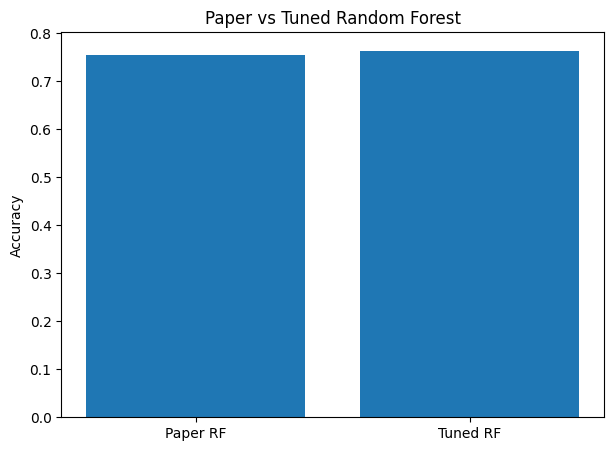

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title(
    "Paper vs Tuned Random Forest"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

In [21]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)

improvement = (
    tuned_accuracy -
    paper_accuracy
) * 100

print(f"Paper RF Accuracy : {paper_accuracy:.4f}")
print(f"Tuned RF Accuracy : {tuned_accuracy:.4f}")
print(f"Improvement : {improvement:.2f}%")

print()

print(
    "The original paper model was faithfully "
    "reproduced. An additional GridSearchCV "
    "experiment was performed to investigate "
    "whether the Random Forest benchmark "
    "could be further improved."
)

FINAL SUMMARY
Paper RF Accuracy : 0.7555
Tuned RF Accuracy : 0.7636
Improvement : 0.81%

The original paper model was faithfully reproduced. An additional GridSearchCV experiment was performed to investigate whether the Random Forest benchmark could be further improved.
